In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [6]:
# Load the digits dataset
digits = load_digits()

print(digits.keys())
print("Data shape:", digits.data.shape)
print("Target shape:", digits.target.shape)

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Data shape: (1797, 64)
Target shape: (1797,)


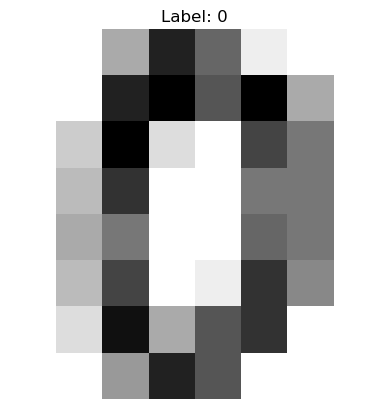

In [7]:
plt.imshow(digits.images[0], cmap="binary")
plt.title(f"Label: {digits.target[0]}")
plt.axis("off")
plt.show()

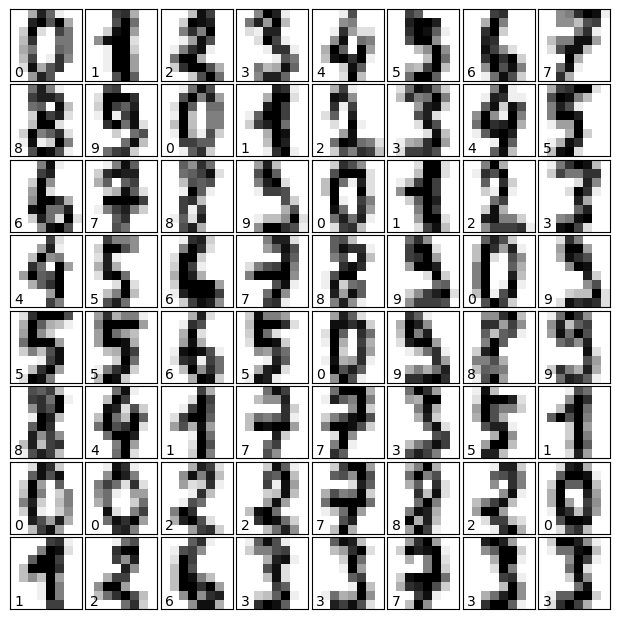

In [8]:
# Show a grid of the first 64 digits with labels
fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, 
                    hspace=0.05, wspace=0.05)

for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation="nearest")
    ax.text(0, 7, str(digits.target[i]))
plt.show()


In [ ]:
# Split into train and test sets
train_data, test_data, train_labels, test_labels = train_test_split(
    digits.data,
    digits.target,
    train_size=0.8,
    test_size=0.2,
    random_state=1  # keep same split as tutorial
)

In [10]:
mlp = MLPClassifier(
    hidden_layer_sizes=(5,),
    activation='logistic',
    alpha=1e-4,
    solver='sgd',
    tol=1e-4,
    random_state=1,
    learning_rate_init=0.3,
    verbose=True
)

mlp.fit(train_data, train_labels)

predictions = mlp.predict(test_data)
acc = accuracy_score(test_labels, predictions)
print("Single-model accuracy:", acc)

Iteration 1, loss = 2.25145782
Iteration 2, loss = 1.97730357
Iteration 3, loss = 1.66620880
Iteration 4, loss = 1.41353830
Iteration 5, loss = 1.29575643
Iteration 6, loss = 1.06663581
Iteration 7, loss = 0.95501010
Iteration 8, loss = 0.94877157
Iteration 9, loss = 0.79341816
Iteration 10, loss = 0.75157247
Iteration 11, loss = 0.86653666
Iteration 12, loss = 0.71381786
Iteration 13, loss = 0.70885072
Iteration 14, loss = 0.74097786
Iteration 15, loss = 0.69329600
Iteration 16, loss = 0.79572329
Iteration 17, loss = 1.01779315
Iteration 18, loss = 0.87236821
Iteration 19, loss = 0.73394899
Iteration 20, loss = 0.79647775
Iteration 21, loss = 0.72042454
Iteration 22, loss = 0.65493148
Iteration 23, loss = 0.62859621
Iteration 24, loss = 0.62145375
Iteration 25, loss = 0.83144748
Iteration 26, loss = 0.74720588
Iteration 27, loss = 0.59300992
Iteration 28, loss = 0.60710209
Iteration 29, loss = 0.55747553
Iteration 30, loss = 0.94831404
Iteration 31, loss = 0.72557691
Iteration 32, los

In [11]:
acc_scores = []

for i in range(5, 35):  # 5, 6, ..., 34  (30 different sizes)
    mlp = MLPClassifier(
        hidden_layer_sizes=(i,),
        activation='logistic',
        random_state=1,
        alpha=1e-4,
        max_iter=10000,
        solver='sgd',
        tol=1e-4,
        learning_rate_init=0.3,
        verbose=False
    )
    mlp.fit(train_data, train_labels)
    predictions = mlp.predict(test_data)
    acc_score = accuracy_score(test_labels, predictions)
    acc_scores.append(acc_score)
    print(i, acc_score)

avg_accuracy = np.mean(acc_scores)
print("\nAverage accuracy over 30 runs:", avg_accuracy)


5 0.8444444444444444
6 0.5777777777777777
7 0.8583333333333333
8 0.8277777777777777
9 0.8916666666666667
10 0.8916666666666667
11 0.9388888888888889
12 0.8916666666666667
13 0.9194444444444444
14 0.9444444444444444
15 0.95
16 0.9555555555555556
17 0.9527777777777777
18 0.95
19 0.9472222222222222
20 0.9722222222222222
21 0.9527777777777777
22 0.9694444444444444
23 0.9611111111111111
24 0.9722222222222222
25 0.9527777777777777
26 0.9666666666666667
27 0.9472222222222222
28 0.9583333333333334
29 0.9611111111111111
30 0.9694444444444444
31 0.9694444444444444
32 0.975
33 0.9611111111111111
34 0.9666666666666667

Average accuracy over 30 runs: 0.9265740740740742
